In [1]:
import pandas as pd

df = pd.read_csv("sql data.csv")

df.head()

C:\Users\sanja\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\sanja\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,date,totalChallan,disposedChallan,pendingChallan,pendingAmount,disposedAmount,totalAmount,pendingCourt,disposedCourt,totalCourt
0,01-01-2015,120,29,91,588600,116860,705460,1,0,1
1,02-01-2015,162,39,123,663350,281425,944775,1,1,2
2,03-01-2015,122,34,88,596900,286950,883850,4,1,5
3,04-01-2015,116,27,89,967350,301600,1268950,3,2,5
4,05-01-2015,162,28,134,877654,103000,980654,2,0,2


In [2]:
# Basic understanding of the dataset

print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (4061, 10)

Column names:
['date', 'totalChallan', 'disposedChallan', 'pendingChallan', 'pendingAmount', 'disposedAmount', 'totalAmount', 'pendingCourt', 'disposedCourt', 'totalCourt']

Data types:
date                 str
totalChallan       int64
disposedChallan    int64
pendingChallan     int64
pendingAmount      int64
disposedAmount     int64
totalAmount        int64
pendingCourt       int64
disposedCourt      int64
totalCourt         int64
dtype: object

Missing values:
date               0
totalChallan       0
disposedChallan    0
pendingChallan     0
pendingAmount      0
disposedAmount     0
totalAmount        0
pendingCourt       0
disposedCourt      0
totalCourt         0
dtype: int64

Duplicate rows:
0


In [3]:
# Convert date from text to proper date format

df["date"] = pd.to_datetime(
    df["date"],
    dayfirst=True,
    errors="coerce"
)

print("Date type:", df["date"].dtype)
print("Date range:", df["date"].min(), "to", df["date"].max())

Date type: datetime64[us]
Date range: 2015-01-01 00:00:00 to 2026-02-13 00:00:00


YEARLY ANALYSIS


,year,total_challans,disposed_challans,pending_challans,total_fine,collected_fine,pending_fine,total_court_cases,disposed_court_cases,pending_court_cases,challan_disposal_rate,fine_collection_rate,court_disposal_rate
0,2015,112492,14952,97540,274505013,55412297,219092716,72621,2411,70210,13.29,20.19,3.32
1,2016,404445,42776,361669,442931780,102563933,340367847,281267,9608,271659,10.58,23.16,3.42
2,2017,593048,289394,303654,1757967913,1173680480,584287433,261077,36764,224313,48.80,66.76,14.08
3,2018,4317842,3366850,950992,8702586933,6686319692,2016267241,715173,173800,541373,77.98,76.83,24.30
4,2019,20628507,13441022,7187485,19851997107,15587127014,4264870093,6699711,2025783,4673928,65.16,78.52,30.24
5,2020,41190446,18689557,22500889,41135235485,20084568756,21050666729,14616678,3264323,11352355,45.37,48.83,22.33
6,2021,42401371,20597664,21803707,50365081755,25955875578,24409206177,13208799,3627056,9581743,48.58,51.54,27.46
7,2022,47649749,23999582,23650167,72718986864,36661025294,36057961570,17292272,3702527,13589745,50.37,50.41,21.41
8,2023,67911658,27837346,40074312,107652904030,42487725509,65165178521,26866820,4541276,22325544,40.99,39.47,16.90
9,2024,81892378,26316839,55575539,128768546344,40065723712,88702822632,32155997,3394839,28761158,32.14,31.11,10.56



TOP 10 HIGH-ACTIVITY DATES


,date,totalChallan,disposedChallan,pendingChallan,totalAmount
3970,2025-11-15,332710,52122,280588,600535619
3974,2025-11-19,332423,52281,280142,656239191
3975,2025-11-20,331999,52313,279686,633648720
3973,2025-11-18,330422,52614,277808,640247220
3968,2025-11-13,330124,55399,274725,636735428
3976,2025-11-21,329886,51392,278494,618580068
3972,2025-11-17,327914,52422,275492,615306244
3982,2025-11-27,323364,50949,272415,608687380
3967,2025-11-12,322801,56248,266553,637813288
4023,2026-01-07,320516,47792,272724,659146066


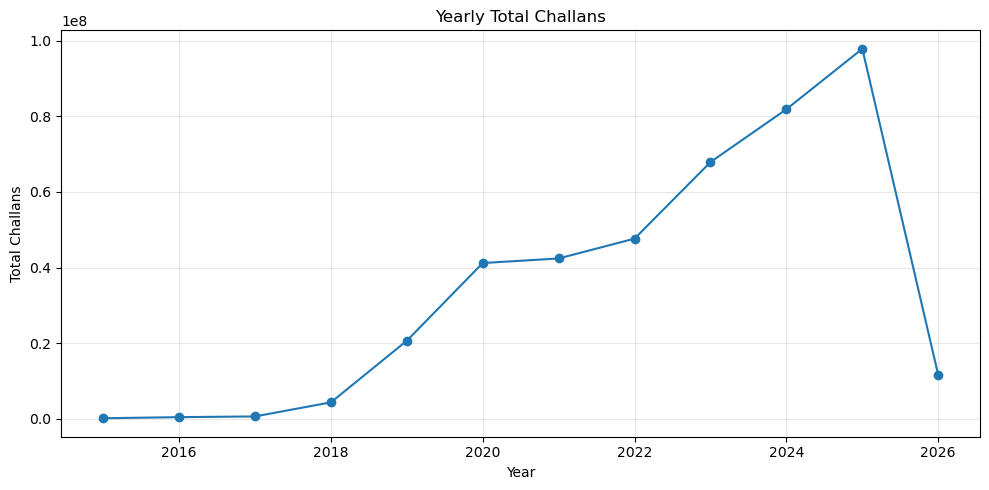

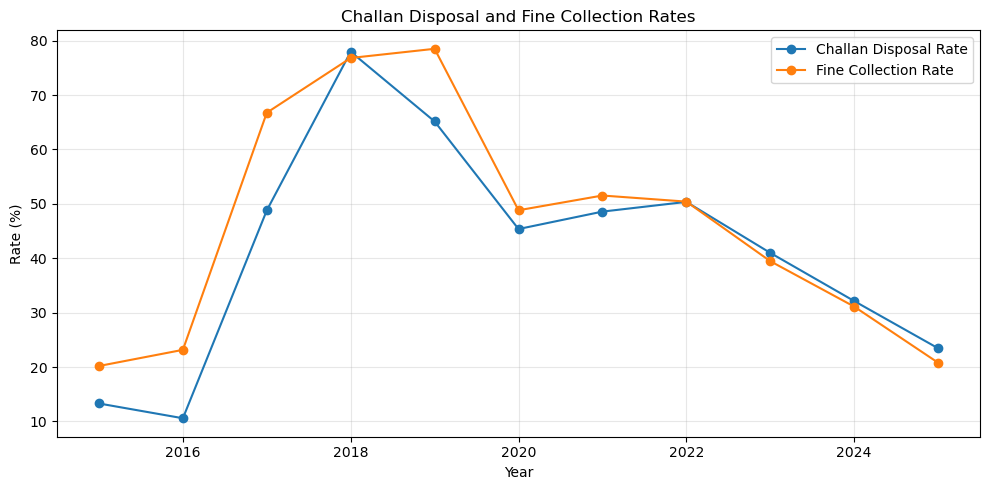

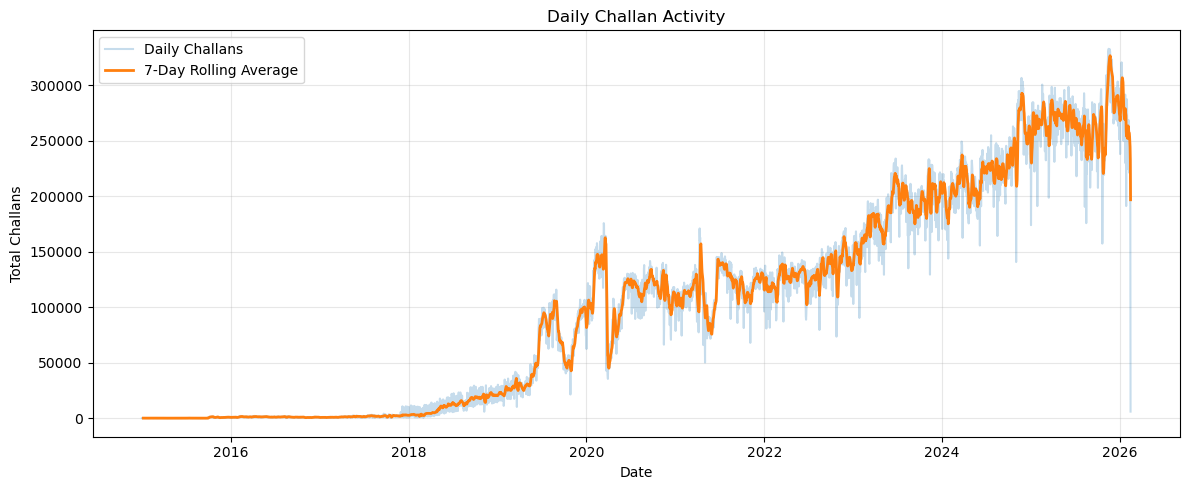


KEY PYTHON INSIGHTS
Highest yearly challan volume: 2025 — 97,884,423 challans
Highest challan disposal rate: 2018 — 77.98%
Highest fine collection rate: 2019 — 78.52%
Highest single-day challan activity: 2025-11-15 — 332,710 challans

Note: 2026 is a partial year and ends on 13-Feb-2026.


In [4]:
# ============================================
# PYTHON EXPLORATORY DATA ANALYSIS
# ============================================

import matplotlib.pyplot as plt

# 1. Create year column
df["year"] = df["date"].dt.year

# 2. Yearly analysis
yearly = (
    df.groupby("year")
      .agg(
          total_challans=("totalChallan", "sum"),
          disposed_challans=("disposedChallan", "sum"),
          pending_challans=("pendingChallan", "sum"),
          total_fine=("totalAmount", "sum"),
          collected_fine=("disposedAmount", "sum"),
          pending_fine=("pendingAmount", "sum"),
          total_court_cases=("totalCourt", "sum"),
          disposed_court_cases=("disposedCourt", "sum"),
          pending_court_cases=("pendingCourt", "sum")
      )
      .reset_index()
)

# 3. Calculate performance rates
yearly["challan_disposal_rate"] = (
    yearly["disposed_challans"] / yearly["total_challans"] * 100
)

yearly["fine_collection_rate"] = (
    yearly["collected_fine"] / yearly["total_fine"] * 100
)

yearly["court_disposal_rate"] = (
    yearly["disposed_court_cases"] / yearly["total_court_cases"] * 100
)

print("YEARLY ANALYSIS")
display(yearly.round(2))


# ============================================
# 4. TOP 10 HIGH-ACTIVITY DATES
# ============================================

top_dates = (
    df[[
        "date",
        "totalChallan",
        "disposedChallan",
        "pendingChallan",
        "totalAmount"
    ]]
    .sort_values("totalChallan", ascending=False)
    .head(10)
)

print("\nTOP 10 HIGH-ACTIVITY DATES")
display(top_dates)


# ============================================
# 5. DAILY 7-DAY ROLLING AVERAGE
# ============================================

daily = df[["date", "totalChallan"]].copy()

daily["rolling_7_day"] = (
    daily["totalChallan"].rolling(7).mean()
)


# ============================================
# CHART 1 — YEARLY CHALLANS
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    yearly["year"],
    yearly["total_challans"],
    marker="o"
)

plt.title("Yearly Total Challans")
plt.xlabel("Year")
plt.ylabel("Total Challans")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================
# CHART 2 — DISPOSAL & COLLECTION RATES
# ============================================

complete_years = yearly[yearly["year"] < 2026]

plt.figure(figsize=(10, 5))

plt.plot(
    complete_years["year"],
    complete_years["challan_disposal_rate"],
    marker="o",
    label="Challan Disposal Rate"
)

plt.plot(
    complete_years["year"],
    complete_years["fine_collection_rate"],
    marker="o",
    label="Fine Collection Rate"
)

plt.title("Challan Disposal and Fine Collection Rates")
plt.xlabel("Year")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================
# CHART 3 — DAILY ACTIVITY + 7-DAY AVERAGE
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    daily["date"],
    daily["totalChallan"],
    alpha=0.25,
    label="Daily Challans"
)

plt.plot(
    daily["date"],
    daily["rolling_7_day"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.title("Daily Challan Activity")
plt.xlabel("Date")
plt.ylabel("Total Challans")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================
# 6. KEY PYTHON INSIGHTS
# ============================================

highest_year = yearly.loc[
    yearly["total_challans"].idxmax()
]

highest_disposal = complete_years.loc[
    complete_years["challan_disposal_rate"].idxmax()
]

highest_collection = complete_years.loc[
    complete_years["fine_collection_rate"].idxmax()
]

highest_day = top_dates.iloc[0]

print("\n" + "=" * 55)
print("KEY PYTHON INSIGHTS")
print("=" * 55)

print(
    f"Highest yearly challan volume: "
    f"{int(highest_year['year'])} — "
    f"{int(highest_year['total_challans']):,} challans"
)

print(
    f"Highest challan disposal rate: "
    f"{int(highest_disposal['year'])} — "
    f"{highest_disposal['challan_disposal_rate']:.2f}%"
)

print(
    f"Highest fine collection rate: "
    f"{int(highest_collection['year'])} — "
    f"{highest_collection['fine_collection_rate']:.2f}%"
)

print(
    f"Highest single-day challan activity: "
    f"{highest_day['date'].date()} — "
    f"{int(highest_day['totalChallan']):,} challans"
)

print(
    "\nNote: 2026 is a partial year and ends on 13-Feb-2026."
)

In [5]:
# Save important Python analysis outputs

from pathlib import Path

output_folder = Path("outputs")
output_folder.mkdir(exist_ok=True)

# Save yearly analysis
yearly.to_csv(
    output_folder / "python_yearly_analysis.csv",
    index=False
)

# Save top activity dates
top_dates.to_csv(
    output_folder / "python_top_activity_dates.csv",
    index=False
)

# Save key insights
with open(output_folder / "python_key_insights.txt", "w") as f:
    f.write(
        f"Highest yearly challan volume: "
        f"{int(highest_year['year'])} — "
        f"{int(highest_year['total_challans']):,} challans\n"
    )

    f.write(
        f"Highest challan disposal rate: "
        f"{int(highest_disposal['year'])} — "
        f"{highest_disposal['challan_disposal_rate']:.2f}%\n"
    )

    f.write(
        f"Highest fine collection rate: "
        f"{int(highest_collection['year'])} — "
        f"{highest_collection['fine_collection_rate']:.2f}%\n"
    )

    f.write(
        f"Highest single-day challan activity: "
        f"{highest_day['date'].date()} — "
        f"{int(highest_day['totalChallan']):,} challans\n"
    )

    f.write(
        "Note: 2026 is a partial year and ends on 13-Feb-2026.\n"
    )

print("Python outputs saved successfully.")
print("Files created:")
print("- outputs/python_yearly_analysis.csv")
print("- outputs/python_top_activity_dates.csv")
print("- outputs/python_key_insights.txt")

Python outputs saved successfully.
Files created:
- outputs/python_yearly_analysis.csv
- outputs/python_top_activity_dates.csv
- outputs/python_key_insights.txt
